# EDA — FIFA World Rankings & FiveThirtyEight SPI
**Sources**:
- `fifa_rankings/` — FIFA official ranking snapshots (2023–2024 CSVs)
- `fivethirtyeight_spi/` — FiveThirtyEight Soccer Power Index: `spi_global_rankings_intl.csv`, `spi_matches.csv`, `spi_matches_latest.csv`

**Purpose**: Compare FIFA rankings and SPI as alternative team strength features to ELO. Understand coverage, update frequency, and correlation with ELO.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

sns.set_theme(style='whitegrid', palette='muted')
FIFA_DATA = Path('../data/raw/fifa_rankings')
SPI_DATA = Path('../data/raw/fivethirtyeight_spi')

## 1. FIFA Rankings — Load All Snapshots

In [2]:
fifa_files = sorted([f for f in os.listdir(FIFA_DATA) if f.endswith('.csv')])
print('FIFA ranking files:', fifa_files)

fifa_dfs = []
for f in fifa_files:
    df = pd.read_csv(FIFA_DATA / f, parse_dates=['rank_date'])
    fifa_dfs.append(df)

fifa = pd.concat(fifa_dfs, ignore_index=True)
print('Combined shape:', fifa.shape)
print('Columns:', fifa.columns.tolist())
print('Date range:', fifa['rank_date'].min(), '->', fifa['rank_date'].max())
print('Unique teams:', fifa['country_full'].nunique())
fifa.head(3)

FIFA ranking files: ['fifa_ranking-2023-07-20.csv', 'fifa_ranking-2024-04-04.csv', 'fifa_ranking-2024-06-20.csv']
Combined shape: (199490, 8)
Columns: ['rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date']
Date range: 1992-12-31 00:00:00 -> 2024-06-20 00:00:00
Unique teams: 232


,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,1.0,Germany,GER,57.0,0.0,0,UEFA,1992-12-31
1,96.0,Syria,SYR,11.0,0.0,0,AFC,1992-12-31
2,97.0,Burkina Faso,BFA,11.0,0.0,0,CAF,1992-12-31


In [3]:
print('Missing values:')
print(fifa.isnull().mean().mul(100).round(2))
print()
print('Points range:', fifa['total_points'].min(), '-', fifa['total_points'].max())
print('Rank range:', fifa['rank'].min(), '-', fifa['rank'].max())

Missing values:
rank               0.01
country_full       0.00
country_abrv       0.00
total_points       0.00
previous_points    0.00
rank_change        0.00
confederation      0.00
rank_date          0.00
dtype: float64

Points range: 0.0 - 2172.0
Rank range: 1.0 - 211.0


## 2. FIFA Rankings — Latest Snapshot Top 30

Latest snapshot: 2024-06-20

Top 30:
 rank   country_full  total_points confederation
  1.0      Argentina       1860.14      CONMEBOL
  2.0         France       1837.47          UEFA
  3.0        Belgium       1797.98          UEFA
  4.0         Brazil       1791.85      CONMEBOL
  5.0        England       1787.88          UEFA
  6.0       Portugal       1747.04          UEFA
  7.0    Netherlands       1746.66          UEFA
  8.0          Spain       1729.92          UEFA
  9.0        Croatia       1728.30          UEFA
 10.0          Italy       1724.37          UEFA
 11.0            USA       1676.52      CONCACAF
 12.0       Colombia       1669.44      CONMEBOL
 12.0        Morocco       1669.44           CAF
 14.0        Uruguay       1663.44      CONMEBOL
 15.0         Mexico       1652.33      CONCACAF
 16.0        Germany       1646.78          UEFA
 17.0          Japan       1628.81           AFC
 18.0        Senegal       1623.34           CAF
 19.0    Switzerland       1617.

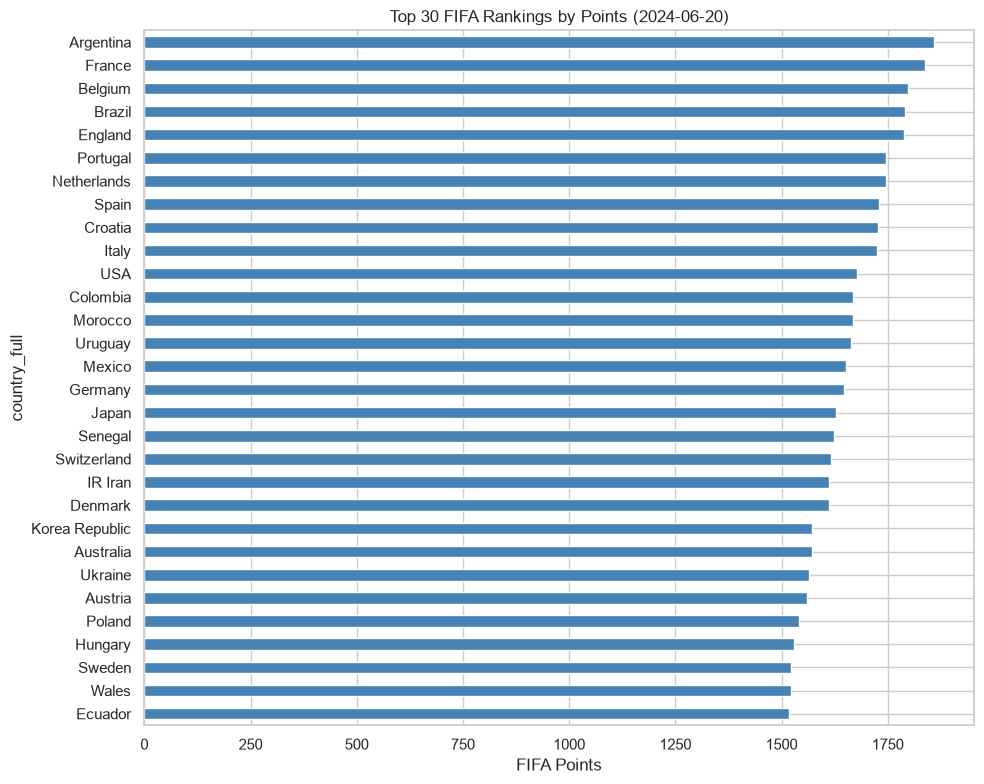

In [4]:
latest_snapshot_date = fifa['rank_date'].max()
latest_fifa = fifa[fifa['rank_date'] == latest_snapshot_date].sort_values('rank')

print(f'Latest snapshot: {latest_snapshot_date.date()}')
print('\nTop 30:')
print(latest_fifa[['rank', 'country_full', 'total_points', 'confederation']].head(30).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
latest_fifa.head(30).sort_values('total_points').plot(
    kind='barh', x='country_full', y='total_points', ax=ax, legend=False, color='steelblue'
)
ax.set_title(f'Top 30 FIFA Rankings by Points ({latest_snapshot_date.date()})')
ax.set_xlabel('FIFA Points')
plt.tight_layout()
plt.show()

## 3. FIFA Rankings — Point Distribution & Confederation Breakdown

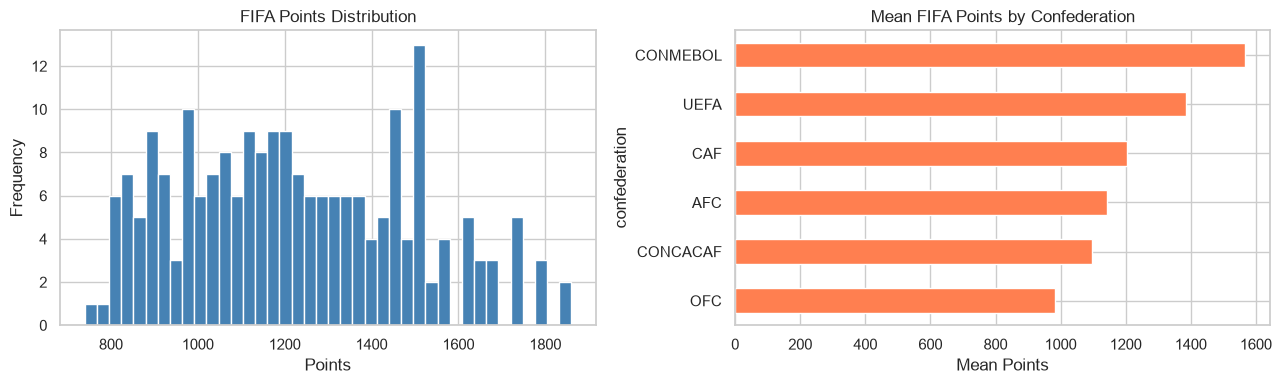

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

latest_fifa['total_points'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('FIFA Points Distribution')
axes[0].set_xlabel('Points')

conf_means = latest_fifa.groupby('confederation')['total_points'].mean().sort_values()
conf_means.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Mean FIFA Points by Confederation')
axes[1].set_xlabel('Mean Points')

plt.tight_layout()
plt.show()

## 4. Snapshot Stability — Rank Changes Between Snapshots

Pivot shape (teams x snapshots): (232, 333)

Rank change 1992-12-31 -> 2024-06-20:
Mean abs change: 31.5
Max rise: -105 (Ukraine)
Max fall: 113 (Bermuda)


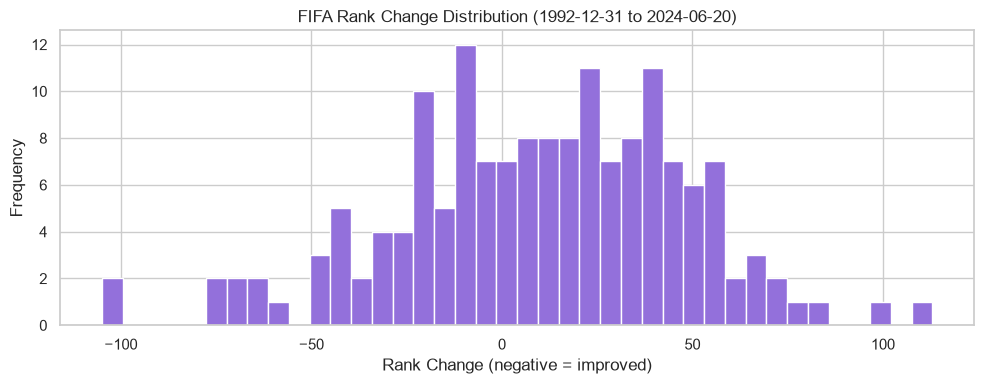

In [6]:
pivot = fifa.pivot_table(index='country_full', columns='rank_date', values='rank')
print('Pivot shape (teams x snapshots):', pivot.shape)

if pivot.shape[1] >= 2:
    cols = sorted(pivot.columns)
    rank_diff = pivot[cols[-1]] - pivot[cols[0]]
    rank_diff = rank_diff.dropna()
    
    print(f'\nRank change {cols[0].date()} -> {cols[-1].date()}:')
    print(f'Mean abs change: {rank_diff.abs().mean():.1f}')
    print(f'Max rise: {rank_diff.min():.0f} ({rank_diff.idxmin()})')
    print(f'Max fall: {rank_diff.max():.0f} ({rank_diff.idxmax()})')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    rank_diff.plot(kind='hist', bins=40, ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title(f'FIFA Rank Change Distribution ({cols[0].date()} to {cols[-1].date()})')
    ax.set_xlabel('Rank Change (negative = improved)')
    plt.tight_layout()
    plt.show()
else:
    print('Only one snapshot available — cannot compute stability')

## 5. FiveThirtyEight SPI — Load & Profile

In [7]:
spi_files = [f for f in os.listdir(SPI_DATA) if f.endswith('.csv')]
print('SPI files:', spi_files)

spi_rankings = pd.read_csv(SPI_DATA / 'spi_global_rankings_intl.csv')
spi_matches = pd.read_csv(SPI_DATA / 'spi_matches.csv', parse_dates=['date'])

# Filter matches to international only (no league column means intl)
print('SPI rankings shape:', spi_rankings.shape)
print('SPI rankings columns:', spi_rankings.columns.tolist())
print()
print('SPI matches shape:', spi_matches.shape)
print('SPI matches date range:', spi_matches['date'].min(), '->', spi_matches['date'].max())
spi_rankings.head(10)

SPI files: ['spi_matches_intl.csv', 'spi_global_rankings_intl.csv', 'spi_matches_latest.csv', 'spi_matches.csv', 'spi_global_rankings.csv']
SPI rankings shape: (220, 7)
SPI rankings columns: ['index', 'rank', 'name', 'confed', 'off', 'def', 'spi']

SPI matches shape: (65977, 24)
SPI matches date range: 2016-07-09 00:00:00 -> 2023-06-04 00:00:00


,index,rank,name,confed,off,def,spi
0,0,1,Brazil,CONMEBOL,3.12,0.28,93.19
1,1,2,Germany,UEFA,3.43,0.67,89.95
2,2,3,Argentina,CONMEBOL,2.84,0.39,89.65
3,3,4,Spain,UEFA,2.60,0.34,88.51
4,4,5,France,UEFA,2.97,0.54,88.30
5,5,6,England,UEFA,2.72,0.44,87.82
6,6,7,Portugal,UEFA,2.78,0.52,87.02
7,7,8,Netherlands,UEFA,2.53,0.55,83.98
8,8,9,Colombia,CONMEBOL,2.17,0.48,81.05
9,9,10,Belgium,UEFA,2.44,0.65,80.92


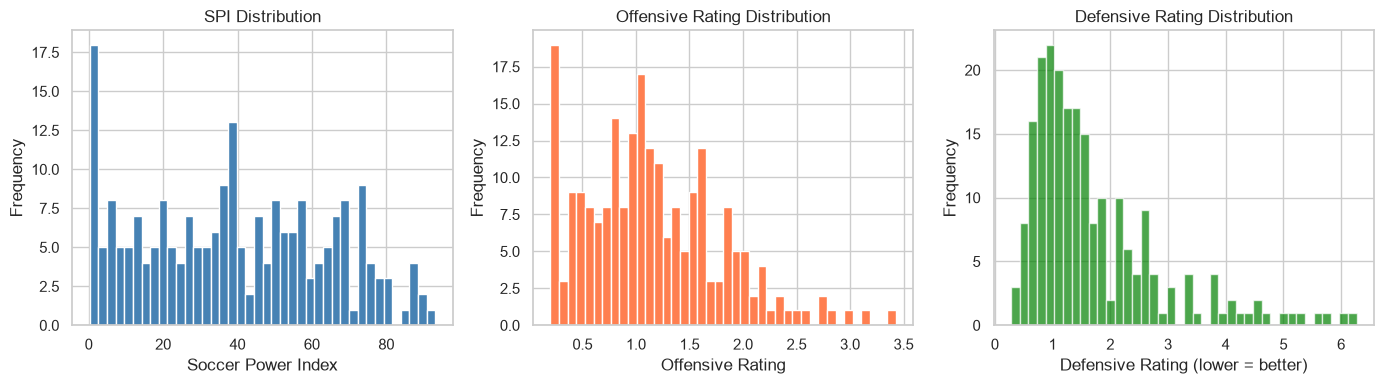

SPI Top 20:
          name   confed   spi  off  def
        Brazil CONMEBOL 93.19 3.12 0.28
       Germany     UEFA 89.95 3.43 0.67
     Argentina CONMEBOL 89.65 2.84 0.39
         Spain     UEFA 88.51 2.60 0.34
        France     UEFA 88.30 2.97 0.54
       England     UEFA 87.82 2.72 0.44
      Portugal     UEFA 87.02 2.78 0.52
   Netherlands     UEFA 83.98 2.53 0.55
      Colombia CONMEBOL 81.05 2.17 0.48
       Belgium     UEFA 80.92 2.44 0.65
         Italy     UEFA 80.65 2.31 0.58
       Uruguay CONMEBOL 79.24 2.08 0.51
       Croatia     UEFA 78.82 2.20 0.60
       Algeria      CAF 78.14 2.37 0.74
       Denmark     UEFA 76.68 2.05 0.60
   Switzerland     UEFA 76.42 2.19 0.70
         Japan      AFC 75.96 2.04 0.62
Czech Republic     UEFA 75.42 2.18 0.74
       Senegal      CAF 74.43 1.96 0.63
        Mexico CONCACAF 74.07 1.88 0.59


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

spi_rankings['spi'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('SPI Distribution')
axes[0].set_xlabel('Soccer Power Index')

spi_rankings['off'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Offensive Rating Distribution')
axes[1].set_xlabel('Offensive Rating')

spi_rankings['def'].plot(kind='hist', bins=40, ax=axes[2], color='green', edgecolor='white', alpha=0.7)
axes[2].set_title('Defensive Rating Distribution')
axes[2].set_xlabel('Defensive Rating (lower = better)')

plt.tight_layout()
plt.show()

print('SPI Top 20:')
print(spi_rankings.sort_values('spi', ascending=False)[['name', 'confed', 'spi', 'off', 'def']].head(20).to_string(index=False))

## 6. SPI Projected Scores — Calibration Check

Matches with both projected and actual scores: 61301


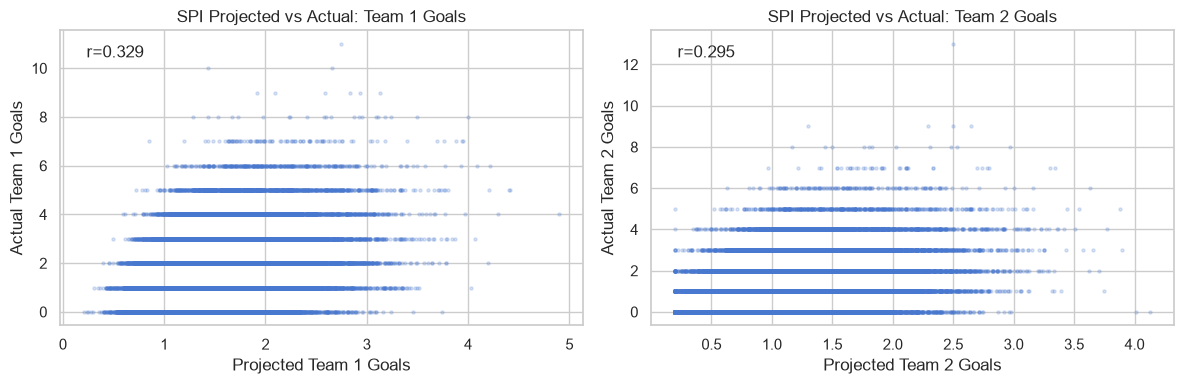

In [9]:
spi_with_results = spi_matches.dropna(subset=['score1', 'score2', 'proj_score1', 'proj_score2'])
print(f'Matches with both projected and actual scores: {len(spi_with_results)}')

if len(spi_with_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, proj_col, actual_col, label in [
        (axes[0], 'proj_score1', 'score1', 'Team 1 Goals'),
        (axes[1], 'proj_score2', 'score2', 'Team 2 Goals'),
    ]:
        ax.scatter(spi_with_results[proj_col], spi_with_results[actual_col], alpha=0.2, s=5)
        ax.set_xlabel(f'Projected {label}')
        ax.set_ylabel(f'Actual {label}')
        ax.set_title(f'SPI Projected vs Actual: {label}')
        # correlation
        r = spi_with_results[proj_col].corr(spi_with_results[actual_col])
        ax.text(0.05, 0.95, f'r={r:.3f}', transform=ax.transAxes, va='top')

    plt.tight_layout()
    plt.show()

## 7. FIFA Rankings vs SPI — Coverage Overlap

In [10]:
fifa_teams = set(latest_fifa['country_full'].str.strip())
spi_teams = set(spi_rankings['name'].str.strip())

print('FIFA teams:', len(fifa_teams))
print('SPI teams:', len(spi_teams))
print('In both:', len(fifa_teams & spi_teams))
print('Only in FIFA:', len(fifa_teams - spi_teams))
print('Only in SPI:', len(spi_teams - fifa_teams))
print()
print('Note: Name mismatches expected — need harmonization before joining')

FIFA teams: 211
SPI teams: 220
In both: 196
Only in FIFA: 15
Only in SPI: 24

Note: Name mismatches expected — need harmonization before joining


## 8. Red Flags Summary

In [11]:
import datetime
red_flags = []
today = datetime.date(2026, 6, 12)

days_stale = (today - latest_snapshot_date.date()).days
if days_stale > 60:
    red_flags.append(f'FIFA rankings data is {days_stale} days stale (last snapshot: {latest_snapshot_date.date()}) — missing 2025–2026 qualifier period; use for historical training only')

if spi_matches['date'].max().year < 2024:
    red_flags.append(f'SPI matches data ends {spi_matches["date"].max().date()} — FiveThirtyEight shut down SPI in 2023; use for validation/calibration reference only, not current team strength')

if red_flags:
    print('RED FLAGS:')
    for f in red_flags:
        print(' -', f)
else:
    print('No red flags.')

print()
print('MODELING NOTE: FIFA rankings are useful as a secondary feature but are less predictive than ELO.')
print('SPI (discontinued 2023) is best used as a calibration reference for historical validation.')

RED FLAGS:
 - FIFA rankings data is 722 days stale (last snapshot: 2024-06-20) — missing 2025–2026 qualifier period; use for historical training only
 - SPI matches data ends 2023-06-04 — FiveThirtyEight shut down SPI in 2023; use for validation/calibration reference only, not current team strength

MODELING NOTE: FIFA rankings are useful as a secondary feature but are less predictive than ELO.
SPI (discontinued 2023) is best used as a calibration reference for historical validation.
